In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/behrad3d/nasa-cmaps'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/readme.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/x.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/datasets/behrad3d/nasa

# Load Libraries

In [25]:
import numpy as np
import pandas as pd
import os

# Define column names

In [26]:
columns = [
    "unit",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

# add sensor names
for i in range(1,22):
    columns.append(f"sensor_{i}")

print(len(columns))

26


# Load FD004 training data

In [27]:
train_path = "/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD004.txt"

train = pd.read_csv(
    train_path,
    sep="\s+",
    header=None,
    names=columns
)

train.head()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_58/677852953.py:5: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


# Calculate RUL labels

In [28]:
# maximum cycle for each engine

max_cycle = (
    train.groupby("unit")["cycle"]
    .max()
    .reset_index()
)

max_cycle.columns = ["unit","max_cycle"]


# merge

train = train.merge(
    max_cycle,
    on="unit",
    how="left"
)


# RUL calculation

train["RUL"] = (
    train["max_cycle"] - train["cycle"]
)


train.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,321,320
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,321,319
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,321,318
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,321,317
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,321,316


# Split engines into FL clients

In [29]:
num_clients = 5

units = train["unit"].unique()

np.random.seed(42)

np.random.shuffle(units)


client_units = np.array_split(
    units,
    num_clients
)


for i,c in enumerate(client_units):
    print(
        f"Client {i+1}:",
        len(c),
        "engines"
    )

Client 1: 50 engines
Client 2: 50 engines
Client 3: 50 engines
Client 4: 50 engines
Client 5: 49 engines


# Create FL client datasets

In [30]:
clients = {}


for i,units in enumerate(client_units):

    client_data = train[
        train["unit"].isin(units)
    ].copy()

    clients[f"airline_{i+1}"] = client_data


for name,data in clients.items():
    print(
        name,
        data.shape
    )

airline_1 (11955, 28)
airline_2 (12238, 28)
airline_3 (12578, 28)
airline_4 (11975, 28)
airline_5 (12503, 28)


# Add sensor heterogeneity (RQ1)

In [31]:
client_sensor_map = {

"airline_1":
[
"op_setting_1",
"op_setting_2",
"op_setting_3"
]+
[f"sensor_{i}" for i in range(1,22)],


"airline_2":
[
"op_setting_1",
"op_setting_2",
"op_setting_3"
]+
[f"sensor_{i}" for i in range(1,16)],


"airline_3":
[
"op_setting_1",
"op_setting_3",
"sensor_2",
"sensor_5",
"sensor_7",
"sensor_10",
"sensor_12",
"sensor_15"
],


"airline_4":
[
"op_setting_1",
"op_setting_2",
"sensor_1",
"sensor_4",
"sensor_8",
"sensor_13",
"sensor_18"
],


"airline_5":
[
"op_setting_2",
"op_setting_3",
"sensor_3",
"sensor_6",
"sensor_11",
"sensor_16",
"sensor_20"
]

}

# Apply sensor availability

In [32]:
client_inputs = {}


for client,data in clients.items():

    features = client_sensor_map[client]

    X = data[features]

    y = data["RUL"]

    client_inputs[client] = {
        "X":X,
        "y":y,
        "features":features
    }


for k,v in client_inputs.items():

    print(
        k,
        v["X"].shape,
        "sensors:",
        len(v["features"])
    )

airline_1 (11955, 24) sensors: 24
airline_2 (12238, 18) sensors: 18
airline_3 (12578, 8) sensors: 8
airline_4 (11975, 7) sensors: 7
airline_5 (12503, 7) sensors: 7


# Import Pytorch

In [33]:
import torch
import torch.nn as nn

# Sensor Adapter

In [34]:
class SensorAdapter(nn.Module):

    def __init__(self, input_dim, latent_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        return self.encoder(x)

# Create One Adapter for Each Airline

In [35]:
client_adapters = {}

for client in client_inputs:

    input_dim = len(client_inputs[client]["features"])

    client_adapters[client] = SensorAdapter(
        input_dim=input_dim,
        latent_dim=64
    )

    print(
        f"{client}: {input_dim} -> 64"
    )

airline_1: 24 -> 64
airline_2: 18 -> 64
airline_3: 8 -> 64
airline_4: 7 -> 64
airline_5: 7 -> 64


# Generate Latent Representations

In [36]:
latent_clients = {}

for client in client_inputs:

    X = client_inputs[client]["X"].values

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    )

    adapter = client_adapters[client]

    with torch.no_grad():

        latent_X = adapter(X_tensor)

    latent_clients[client] = {

        "X": latent_X.numpy(),

        "y": client_inputs[client]["y"].values
    }

    print(
        client,
        latent_X.shape
    )

airline_1 torch.Size([11955, 64])
airline_2 torch.Size([12238, 64])
airline_3 torch.Size([12578, 64])
airline_4 torch.Size([11975, 64])
airline_5 torch.Size([12503, 64])


#  Analysis Till now

**Challenge-01**

1. C-MAPSS has no airline/operator information
2. One centralized dataset
3. No airline ID
4. No organize Boundary

**Solution-01**

Airline 1 → Engine 1-50
Airline 2 → Engine 51-100
Airline 3 → Engine 101-150
...
...

Client 1 data
Client 2 data
Client 3 data
        |
        |
     FL Server
     
**Challenge-02**

Different operators have different sensor availability
*Traditional FL/ other model wants* --> Input size = same
*But we have* -->
Client A:
(batch, 24)

Client B:
(batch, 18)

Client C:
(batch, 8)

**Solution-02**

We preserved each operator's original sensor availability.
We did NOT:

* Remove sensors
* Force common sensors
* Exclude clients

This directly matches RQ1.

**Challenge-03**

Need a common representation space
We need:
Different sensors
↓
Same mathematical space
*Before* --> 
Airline A:
24 dimensions

Airline B:
18 dimensions

Airline C:
8 dimensions

*After* --> All in 64 dim

**Solution-03**

Introduced a local sensor adapter.

*Architecture:*
Original sensors
        |
        |
   Sensor Adapter
        |
        |
64-dimensional vector

**Challenge-04**

Every client need own encoder. Because (24,64) can't accept (18,64)

**Solution-04**

Create one adapter for each client has its own sensor → health representation mapping
While producing --> same latent dimension

Overall this mapping approach easier the communication of different operators and lower information loss.

**Final Pipeline**

NASA C-MAPSS
        |
        |
Split into virtual airlines
        |
        |
Different sensor availability
        |
        |
Local Sensor Adapter
        |
        |
Shared 64-D latent space


****

**Create sequences from latent features**

In [37]:
def create_sequences(X, y, window=30):

    X_seq = []
    y_seq = []

    for i in range(len(X)-window):

        X_seq.append(
            X[i:i+window]
        )

        y_seq.append(
            y[i+window]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

# Apply to each Airline

In [38]:
sequence_clients = {}

for client in latent_clients:

    X = latent_clients[client]["X"]
    y = latent_clients[client]["y"]

    X_seq, y_seq = create_sequences(
        X,
        y,
        window=30
    )

    sequence_clients[client] = {
        "X": X_seq,
        "y": y_seq
    }

    print(
        client,
        X_seq.shape,
        y_seq.shape
    )

airline_1 (11925, 30, 64) (11925,)
airline_2 (12208, 30, 64) (12208,)
airline_3 (12548, 30, 64) (12548,)
airline_4 (11945, 30, 64) (11945,)
airline_5 (12473, 30, 64) (12473,)


# Shared LSTM

In [39]:
import torch
import torch.nn as nn


class FederatedLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )


    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)

# Create Client Dataset

In [40]:
from torch.utils.data import TensorDataset, DataLoader


client_loaders = {}


for client in sequence_clients:

    X = torch.tensor(
        sequence_clients[client]["X"],
        dtype=torch.float32
    )

    y = torch.tensor(
        sequence_clients[client]["y"],
        dtype=torch.float32
    )


    dataset = TensorDataset(
        X,y
    )


    client_loaders[client] = DataLoader(
        dataset,
        batch_size=64,
        shuffle=True
    )

# Fedarated Training

**Single FL Round**

In [41]:
def train_client(model,loader,epochs=1):

    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    loss_fn=nn.MSELoss()


    model.train()


    for X,y in loader:

        optimizer.zero_grad()

        pred=model(X)

        loss=loss_fn(
            pred.squeeze(),
            y
        )

        loss.backward()

        optimizer.step()


    return model.state_dict()

**FedAvg**

In [42]:
def fedavg(weights):

    new_weights={}

    for key in weights[0]:

        new_weights[key]=torch.mean(
            torch.stack(
                [
                    w[key].float()
                    for w in weights
                ],
                dim=0
            ),
            dim=0
        )

    return new_weights

# Run FL Round

In [43]:
global_model = FederatedLSTM()


for round in range(5):

    client_weights=[]


    for client in client_loaders:

        local_model = FederatedLSTM()

        local_model.load_state_dict(
            global_model.state_dict()
        )


        w=train_client(
            local_model,
            client_loaders[client]
        )


        client_weights.append(w)



    new_weights=fedavg(
        client_weights
    )


    global_model.load_state_dict(
        new_weights
    )


    print(
        "FL round",
        round+1,
        "completed"
    )

FL round 1 completed
FL round 2 completed
FL round 3 completed
FL round 4 completed
FL round 5 completed


# Now Prediction Phase

# Create Fault Labels

In [44]:
class SensorAdapter(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Linear(128,64)

        )


    def forward(self,x):

        return self.encoder(x)



client_adapters={}


latent_clients={}


for client,data in clients.items():

    features = client_sensor_map[client]

    X = torch.tensor(
        data[features].values,
        dtype=torch.float32
    )


    adapter = SensorAdapter(
        len(features)
    )


    client_adapters[client]=adapter


    with torch.no_grad():

        latent = adapter(X)


    latent_clients[client]={

        "X":latent.numpy(),

        "RUL":data["RUL"].values

    }


**APPPLY**

In [45]:
def create_sequences(X,y,window=30):

    xs=[]
    ys=[]

    for i in range(len(X)-window):

        xs.append(
            X[i:i+window]
        )

        ys.append(
            y[i+window]
        )


    return np.array(xs),np.array(ys)



sequence_clients={}


for client in latent_clients:


    X,y = create_sequences(
        latent_clients[client]["X"],
        latent_clients[client]["RUL"]
    )


    fault = (y<=50).astype(float)


    sequence_clients[client]={

        "X":X,
        "RUL":y,
        "fault":fault
    }

# DataLoader

In [46]:
loaders={}


for client,data in sequence_clients.items():


    X=torch.tensor(
        data["X"],
        dtype=torch.float32
    )

    y=torch.tensor(
        data["RUL"],
        dtype=torch.float32
    )


    f=torch.tensor(
        data["fault"],
        dtype=torch.float32
    )


    loaders[client]=DataLoader(

        TensorDataset(X,y,f),

        batch_size=64,

        shuffle=True
    )


# Modify LSTM Model

In [47]:
class FL_LSTM(nn.Module):

    def __init__(self):

        super().__init__()


        self.lstm=nn.LSTM(

            input_size=64,

            hidden_size=128,

            num_layers=2,

            batch_first=True
        )


        self.rul_head=nn.Sequential(

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)

        )


        self.fault_head=nn.Sequential(

            nn.Linear(128,32),
            nn.ReLU(),
            nn.Linear(32,1),
            nn.Sigmoid()

        )


    def forward(self,x):

        out,_=self.lstm(x)

        h=out[:,-1,:]


        return (
            self.rul_head(h).squeeze(),
            self.fault_head(h).squeeze()
        )


# Client Training

In [48]:
def train_client(model,loader):

    opt=torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )


    mse=nn.MSELoss()
    bce=nn.BCELoss()


    model.train()


    for X,y,f in loader:


        opt.zero_grad()


        pred_rul,pred_fault=model(X)


        loss1=mse(
            pred_rul,
            y
        )


        loss2=bce(
            pred_fault,
            f
        )


        loss=loss1+loss2


        loss.backward()

        opt.step()


    return model.state_dict()

# FedAvg

In [49]:
def fedavg(weights):

    result={}


    for key in weights[0]:

        result[key]=torch.mean(

            torch.stack(
                [
                w[key].float()
                for w in weights
                ]
            ),

            dim=0
        )


    return result

# Training

In [50]:
global_model=FL_LSTM()


for r in range(5):


    local_weights=[]


    for client in loaders:


        local_model=FL_LSTM()

        local_model.load_state_dict(
            global_model.state_dict()
        )


        w=train_client(
            local_model,
            loaders[client]
        )


        local_weights.append(w)



    global_model.load_state_dict(
        fedavg(local_weights)
    )


    print(
        "Round",
        r+1,
        "completed"
    )


Round 1 completed
Round 2 completed
Round 3 completed
Round 4 completed
Round 5 completed


# Prediction

In [51]:
# ------------------------------------------------------------
# Testing / Evaluation
# ------------------------------------------------------------

test_client = "airline_1"


# get test sequences from train-derived split
X_test = sequence_clients[test_client]["X"]

y_true = sequence_clients[test_client]["RUL"]

fault_true = sequence_clients[test_client]["fault"]



# numpy -> torch

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)



# Prediction

global_model.eval()

with torch.no_grad():

    pred_rul, pred_fault_prob = global_model(
        X_test
    )



# torch -> numpy

pred_rul = pred_rul.cpu().numpy()

pred_fault_prob = pred_fault_prob.cpu().numpy()



# convert probability to class

pred_fault = (
    pred_fault_prob > 0.5
).astype(int)



# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

from sklearn.metrics import accuracy_score, average_precision_score


# RUL RMSE

rmse = np.sqrt(
    np.mean(
        (y_true - pred_rul) ** 2
    )
)


print(
    "RUL RMSE:",
    rmse
)



# Fault accuracy

fault_acc = accuracy_score(
    fault_true,
    pred_fault
)


print(
    "Fault Accuracy:",
    fault_acc
)



# Fault AUPRC

auprc = average_precision_score(
    fault_true,
    pred_fault_prob
)


print(
    "Fault AUPRC:",
    auprc
)



# ------------------------------------------------------------
# Sample predictions
# ------------------------------------------------------------

print("\nExample predictions:")


for i in range(5):

    print(
        f"Sample {i+1}: "
        f"Actual RUL={y_true[i]:.2f}, "
        f"Predicted RUL={pred_rul[i]:.2f}, "
        f"Fault Probability={pred_fault_prob[i]:.3f}"
    )

RUL RMSE: 88.8671128684081
Fault Accuracy: 0.7861635220125787
Fault AUPRC: 0.2138364779874214

Example predictions:
Sample 1: Actual RUL=190.00, Predicted RUL=135.63, Fault Probability=0.202
Sample 2: Actual RUL=189.00, Predicted RUL=135.63, Fault Probability=0.202
Sample 3: Actual RUL=188.00, Predicted RUL=135.63, Fault Probability=0.202
Sample 4: Actual RUL=187.00, Predicted RUL=135.63, Fault Probability=0.202
Sample 5: Actual RUL=186.00, Predicted RUL=135.63, Fault Probability=0.202


# Training to save loss

In [52]:
# ------------------------------------------------------------
# Federated Training with Loss Tracking
# ------------------------------------------------------------

global_model = FL_LSTM()

round_losses = []


for r in range(5):

    local_weights = []
    client_losses = []


    for client in loaders:


        local_model = FL_LSTM()

        local_model.load_state_dict(
            global_model.state_dict()
        )


        opt=torch.optim.Adam(
            local_model.parameters(),
            lr=0.001
        )


        mse=nn.MSELoss()
        bce=nn.BCELoss()


        local_model.train()

        total_loss=0


        for X,y,f in loaders[client]:


            opt.zero_grad()


            pred_rul,pred_fault = local_model(X)


            loss_rul=mse(
                pred_rul,
                y
            )


            loss_fault=bce(
                pred_fault,
                f
            )


            loss=loss_rul+loss_fault


            loss.backward()

            opt.step()


            total_loss += loss.item()


        client_losses.append(
            total_loss / len(loaders[client])
        )


        local_weights.append(
            local_model.state_dict()
        )


    global_model.load_state_dict(
        fedavg(local_weights)
    )


    avg_loss=np.mean(client_losses)

    round_losses.append(avg_loss)


    print(
        f"Round {r+1}, Loss {avg_loss:.4f}"
    )

Round 1, Loss 14601.1529
Round 2, Loss 8207.0875
Round 3, Loss 8012.9859
Round 4, Loss 8011.0834
Round 5, Loss 8007.3139


# Fwderated Training Loss Curve

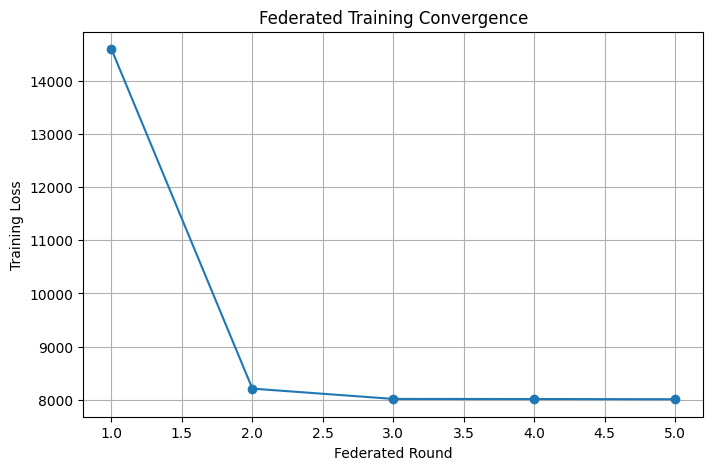

In [53]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(round_losses)+1),
    round_losses,
    marker='o'
)


plt.xlabel("Federated Round")
plt.ylabel("Training Loss")

plt.title(
    "Federated Training Convergence"
)

plt.grid(True)

plt.show()

# Actual RUL vs Predicted RUL Curve

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

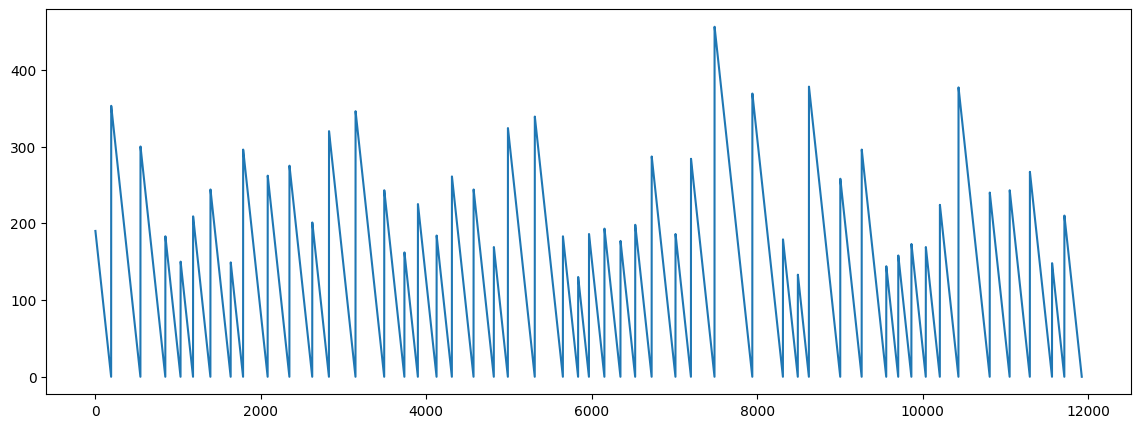

In [55]:
plt.figure(figsize=(14,5))


plt.plot(
    y_true,
    label="Actual RUL"
)


plt.plot(
    pred_rul,
    label="Predicted RUL"
)


plt.xlabel(
    "Engine Cycle Samples"
)

plt.ylabel(
    "RUL"
)


plt.title(
    "Actual vs Predicted Remaining Useful Life"
)


plt.legend()

plt.grid(True)

plt.show()

# Prediction Error Curve

In [56]:
error = y_true - pred_rul


plt.figure(figsize=(14,5))


plt.plot(
    error
)


plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel(
    "Samples"
)

plt.ylabel(
    "RUL Error"
)


plt.title(
    "Prediction Error Over Time"
)


plt.grid(True)

plt.show()

TypeError: unsupported operand type(s) for -: 'numpy.ndarray' and 'Tensor'

# Early Fault Detection Curve

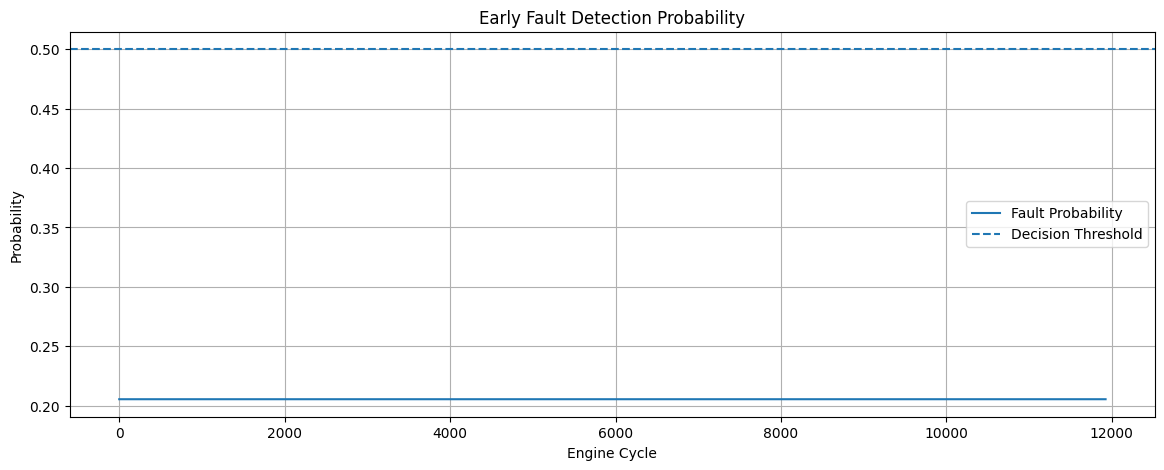

In [57]:
global_model.eval()

with torch.no_grad():

    _,fault_prob = global_model(
        X_test
    )


fault_prob=fault_prob.numpy()


plt.figure(figsize=(14,5))


plt.plot(
    fault_prob,
    label="Fault Probability"
)


plt.axhline(
    0.5,
    linestyle="--",
    label="Decision Threshold"
)


plt.xlabel(
    "Engine Cycle"
)

plt.ylabel(
    "Probability"
)


plt.title(
    "Early Fault Detection Probability"
)


plt.legend()

plt.grid(True)

plt.show()

# Client-wise FL Performance

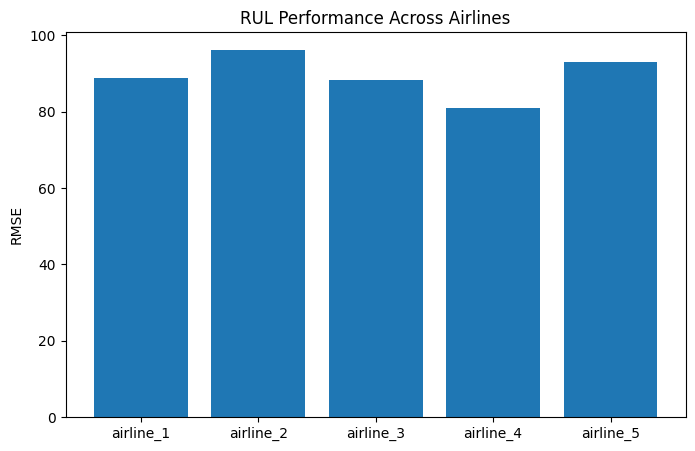

In [58]:
client_rmse={}


for client,data in sequence_clients.items():

    X=torch.tensor(
        data["X"],
        dtype=torch.float32
    )

    y=data["RUL"]


    with torch.no_grad():

        pred,_=global_model(X)


    pred=pred.numpy()


    rmse=np.sqrt(
        np.mean(
            (y-pred)**2
        )
    )


    client_rmse[client]=rmse



plt.figure(figsize=(8,5))


plt.bar(
    client_rmse.keys(),
    client_rmse.values()
)


plt.ylabel("RMSE")

plt.title(
    "RUL Performance Across Airlines"
)


plt.show()

# Overall Pipeline

In [ ]:
NASA C-MAPSS FD004
        |
        |
Calculate RUL Labels
        |
        |
Split Engines into 5 Airlines (FL Clients)
        |
        |
Introduce Sensor Heterogeneity
        |
        |
------------------------------------------------
Airline 1 -> 24 sensors
Airline 2 -> 18 sensors
Airline 3 -> 8 sensors
Airline 4 -> 7 sensors
Airline 5 -> 7 sensors
------------------------------------------------
        |
        |
Client-Specific Sensor Adapters
(24→64, 18→64, 8→64, 7→64)
        |
        |
Shared 64-Dimensional Latent Space
        |
        |
Sliding Window Creation
(window = 30 cycles)
        |
        |
Sequences:
(samples, 30, 64)
        |
        |
Federated Multi-Task LSTM
        |
        |
------------------------------------------------
|                                              |
|                                              |
RUL Head                                  Fault Head
Regression                                Classification
|                                              |
Predicted RUL                          Fault Probability
------------------------------------------------
        |
        |
Local Training at Each Airline
        |
        |
FedAvg Aggregation Server
        |
        |
Global Model Update
        |
        |
Repeat FL Rounds
        |
        |
Final Global Model
        |
        |
Evaluation
        |
        |
------------------------------------------------
RUL Metrics:
• RMSE
• MAE (optional)

Fault Metrics:
• Accuracy
• Precision
• Recall
• F1-score
• AUPRC
------------------------------------------------
        |
        |
Visualization
        |
        |
------------------------------------------------
• FL Training Loss Curve
• Actual vs Predicted RUL Curve
• Prediction Error Curve
• Fault Probability Curve
• Client-wise RMSE Comparison
------------------------------------------------